In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [201]:
data = pd.read_csv("credit_risk.csv")
print(data.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


## Data Cleaning

In [202]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [203]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [204]:
data.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [205]:
data ["person_emp_length"]=data["person_emp_length"].fillna(data["person_emp_length"].median())
data["loan_int_rate"]=data["loan_int_rate"].groupby(data["loan_grade"]).transform(lambda x: x.fillna(x.median()))

In [206]:
data.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [207]:
cat_cols=data.select_dtypes(include=['object', 'category']).apply(pd.Series.value_counts)
cat_cols.sum()

person_home_ownership        32581.0
loan_intent                  32581.0
loan_grade                   32581.0
cb_person_default_on_file    32581.0
dtype: float64

## EDA

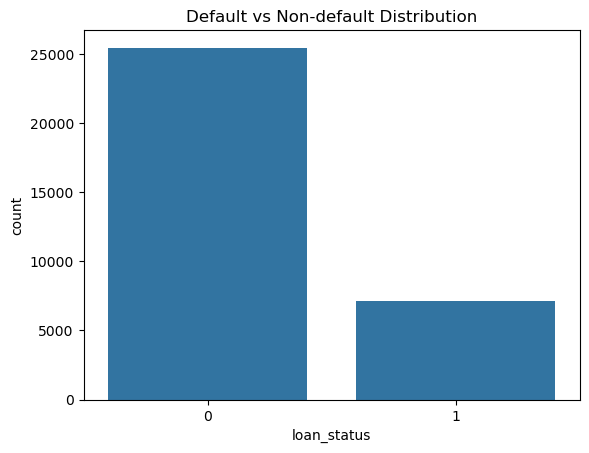

In [208]:
sns.countplot(data=data, x='loan_status')
plt.title('Default vs Non-default Distribution')
plt.show()

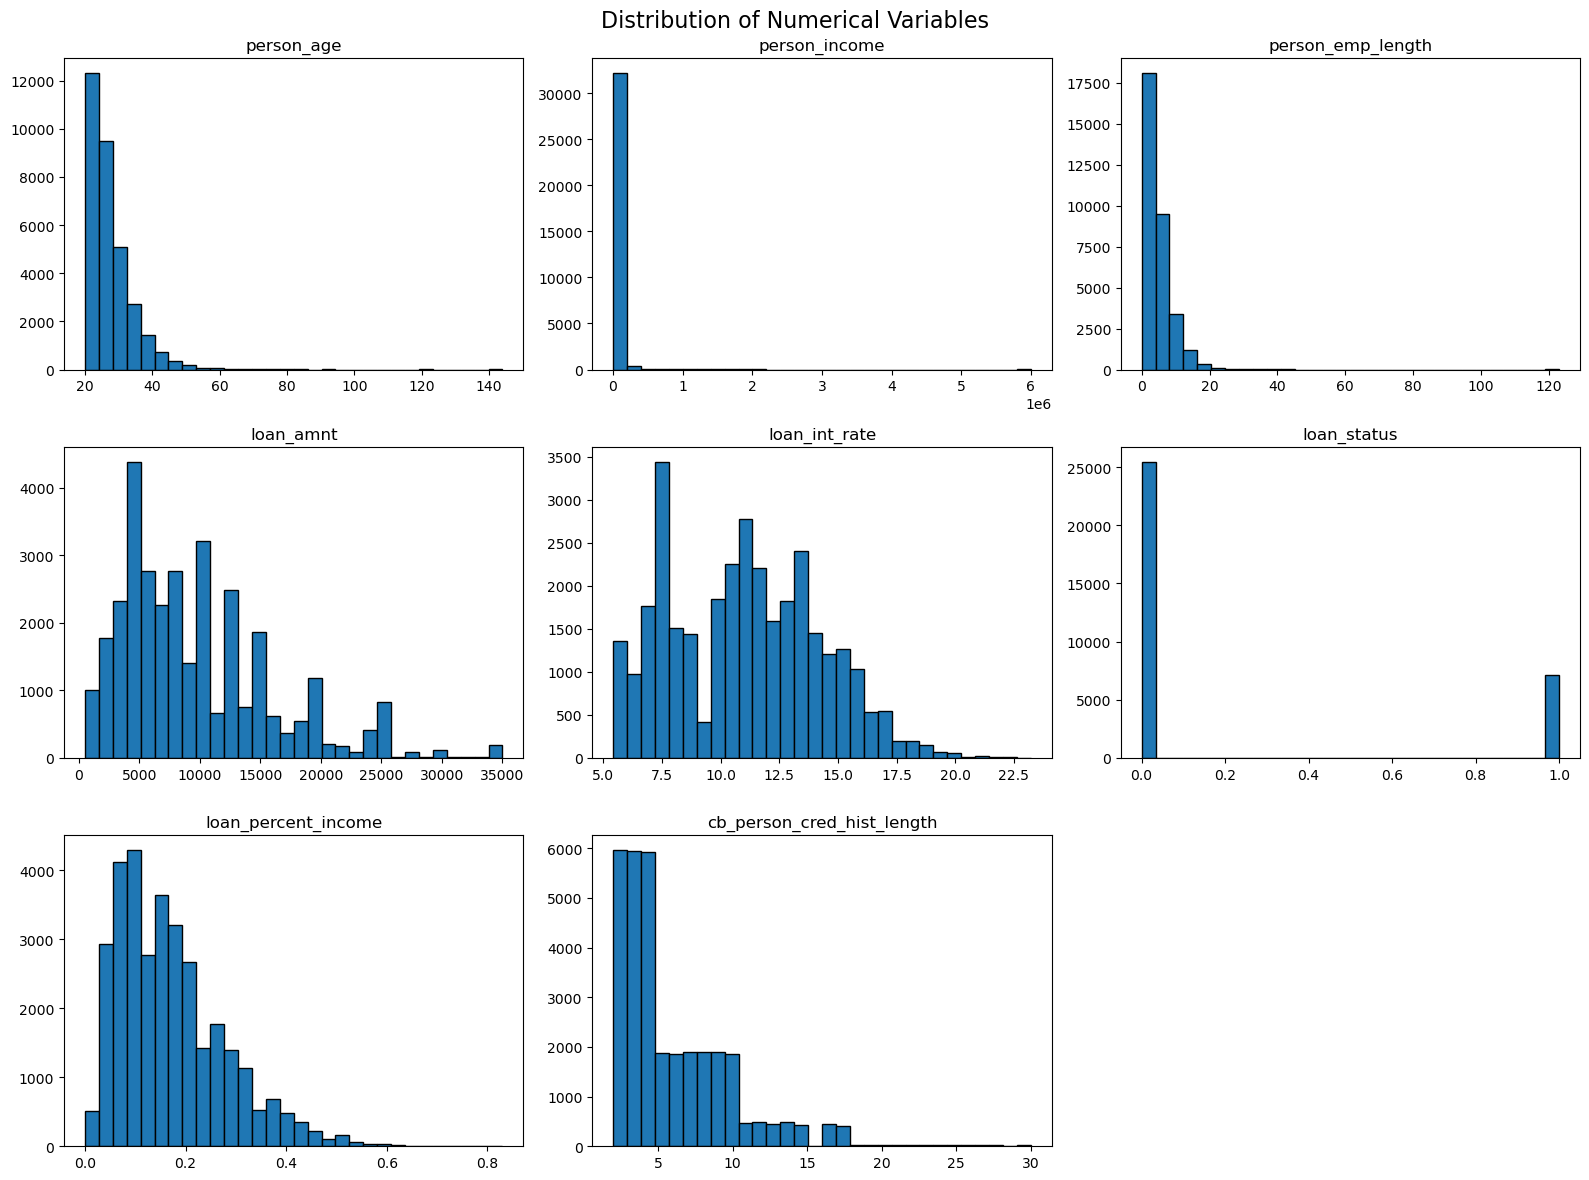

In [209]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

data[num_cols].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor='black',
    grid=False
)

plt.suptitle('Distribution of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

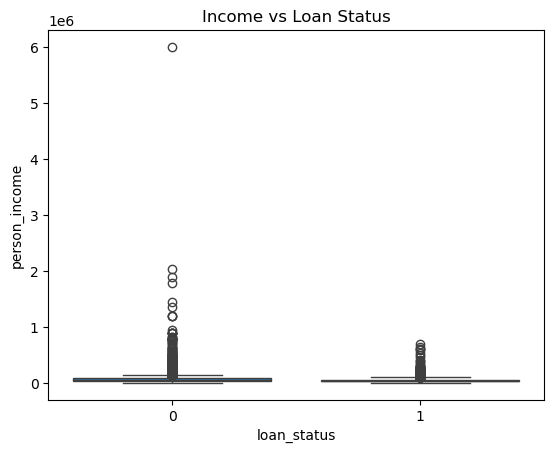

In [210]:
sns.boxplot(data=data, x='loan_status', y='person_income')
plt.title('Income vs Loan Status')
plt.show()

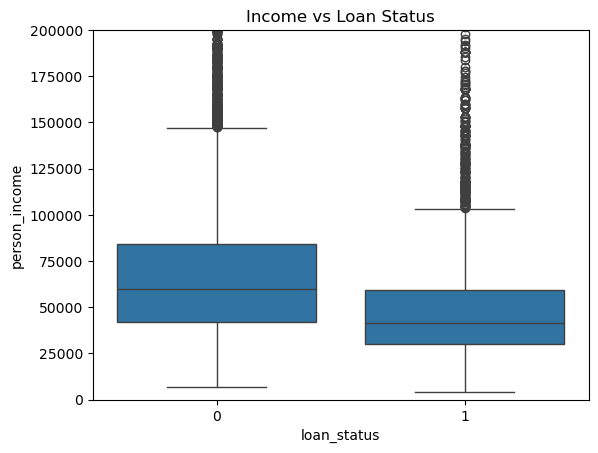

In [211]:
sns.boxplot(data=data, x='loan_status', y='person_income')
plt.ylim(0, 200000)
plt.title('Income vs Loan Status')
plt.show()

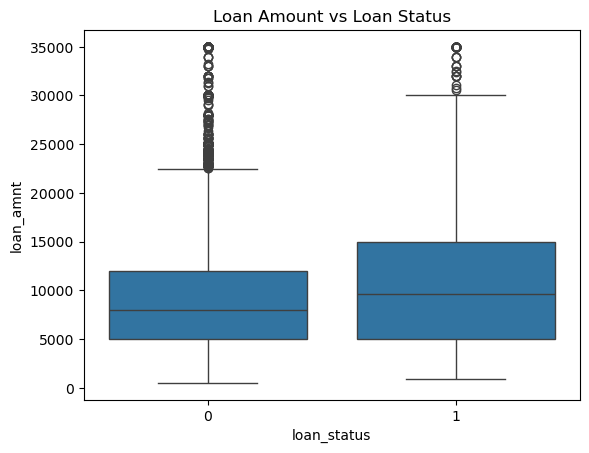

In [212]:
sns.boxplot(data=data, x='loan_status', y='loan_amnt')
plt.title('Loan Amount vs Loan Status')
plt.show()

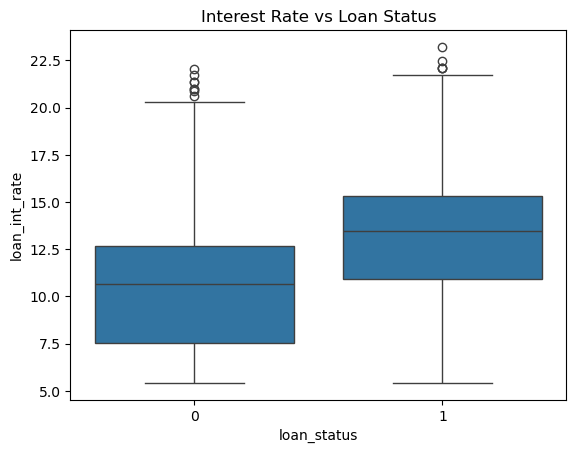

In [213]:
sns.boxplot(data=data, x='loan_status', y='loan_int_rate')
plt.title('Interest Rate vs Loan Status')
plt.show()

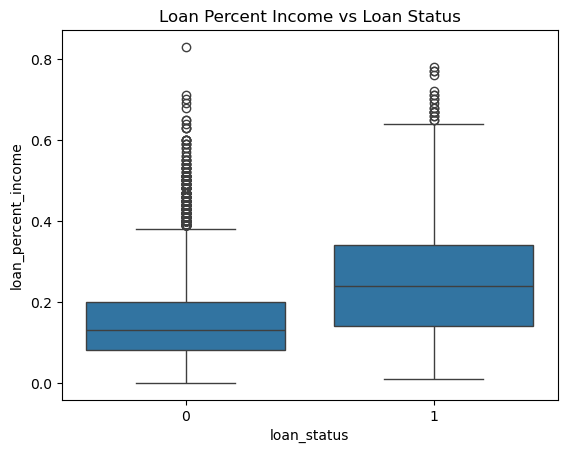

In [214]:
sns.boxplot(data=data, x='loan_status', y='loan_percent_income')
plt.title('Loan Percent Income vs Loan Status')
plt.show()

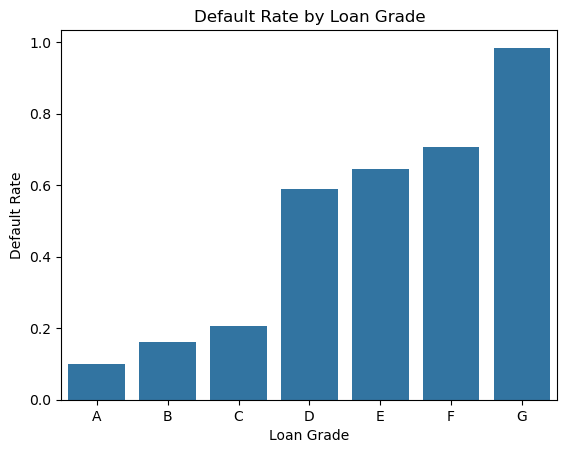

In [215]:
grade_default = data.groupby('loan_grade')['loan_status'].mean().sort_index()

sns.barplot(x=grade_default.index, y=grade_default.values)
plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate')
plt.xlabel('Loan Grade')
plt.show()

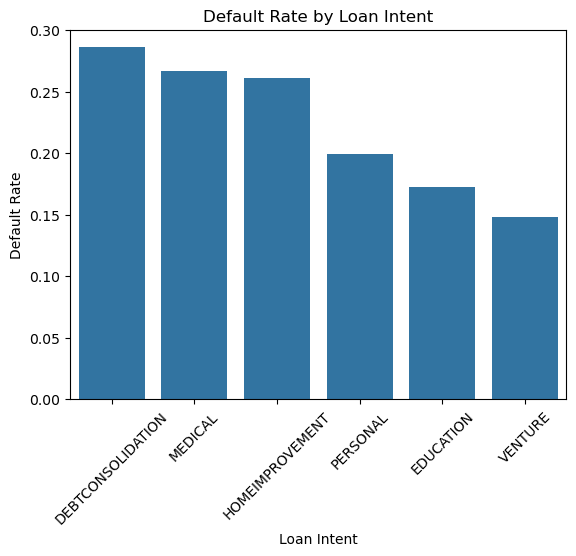

In [216]:
intent_default = data.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)

sns.barplot(x=intent_default.index, y=intent_default.values)
plt.xticks(rotation=45)
plt.title('Default Rate by Loan Intent')
plt.ylabel('Default Rate')
plt.xlabel('Loan Intent')
plt.show()

In [ ]:
num_cols = data.select_dtypes(include=['number']).columns.tolist()

In [217]:
plt.figure(figsize=(10, 6))
sns.heatmap(data[num_cols + ['loan_status']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

KeyError: "None of [Index(['person_ageloan_status', 'person_incomeloan_status',\n       'person_emp_lengthloan_status', 'loan_amntloan_status',\n       'loan_int_rateloan_status', 'loan_statusloan_status',\n       'loan_percent_incomeloan_status',\n       'cb_person_cred_hist_lengthloan_status'],\n      dtype='object')] are in the [columns]"

<Figure size 1000x600 with 0 Axes>

## Feature Engineering

#### Risk category using

Text(0.5, 0, 'Income Risk Category')

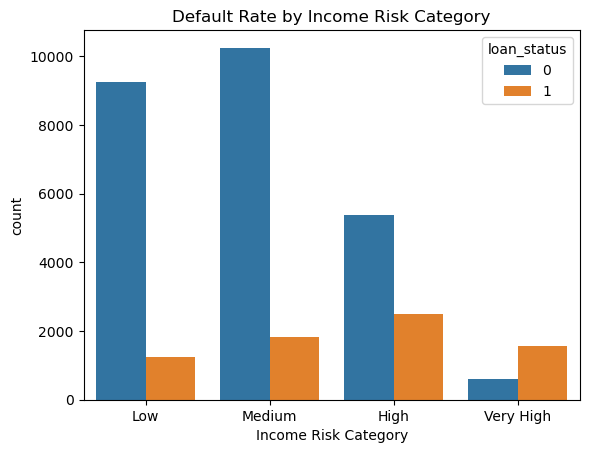

In [ ]:
data['income_risk_category'] = pd.cut(
    data['loan_percent_income'],
    bins=[0, 0.10, 0.20, 0.35, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)
sns.countplot(data=data, x='income_risk_category', hue='loan_status')
plt.title('Default Rate by Income Risk Category')
plt.xlabel('Income Risk Category') 

In [ ]:
data['interest_rate_category'] = pd.cut(
    data['loan_int_rate'],
    bins=[-np.inf, 10, 15, np.inf],
    labels=['low', 'medium', 'high']
)

In [ ]:
categorical_cols = data.select_dtypes(include=['object', 'category']).columns
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
data_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,interest_rate_category,person_home_ownership_OTHER,...,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,income_risk_category_Medium,income_risk_category_High,income_risk_category_Very High
0,22,59000,123.0,35000,16.02,1,0.59,3,high,False,...,False,False,True,False,False,False,True,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,medium,False,...,True,False,False,False,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,medium,False,...,False,True,False,False,False,False,False,False,False,True
3,23,65500,4.0,35000,15.23,1,0.53,2,high,False,...,False,True,False,False,False,False,False,False,False,True
4,24,54400,8.0,35000,14.27,1,0.55,4,medium,False,...,False,True,False,False,False,False,True,False,False,True


In [ ]:
X = data_encoded.drop('loan_status', axis=1)
y = data_encoded['loan_status']

remaining_categorical_cols = X.select_dtypes(include=['object', 'category']).columns
if len(remaining_categorical_cols) > 0:
    raise ValueError(f"Categorical columns still need encoding: {list(remaining_categorical_cols)}")

In [ ]:
X

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,interest_rate_category,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,income_risk_category_Medium,income_risk_category_High,income_risk_category_Very High
0,22,59000,123.0,35000,16.02,0.59,3,high,False,False,...,False,False,True,False,False,False,True,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,medium,False,True,...,True,False,False,False,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,medium,False,False,...,False,True,False,False,False,False,False,False,False,True
3,23,65500,4.0,35000,15.23,0.53,2,high,False,False,...,False,True,False,False,False,False,False,False,False,True
4,24,54400,8.0,35000,14.27,0.55,4,medium,False,False,...,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0.11,30,medium,False,False,...,False,True,False,False,False,False,False,True,False,False
32577,54,120000,4.0,17625,7.49,0.15,19,low,False,False,...,False,False,False,False,False,False,False,True,False,False
32578,65,76000,3.0,35000,10.99,0.46,28,medium,False,False,...,True,False,False,False,False,False,False,False,False,True
32579,56,150000,5.0,15000,11.48,0.10,26,medium,False,False,...,True,False,False,False,False,False,False,False,False,False


## Models Training

In [ ]:
# tain/test split the data 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

ValueError: Cannot cast object dtype to float64

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.825073,0.573822,0.770745,0.657863,0.874076
1,Random Forest,0.932331,0.963173,0.717300,0.822249,0.930911
2,Gradient Boosting,0.921283,0.920444,0.699719,0.795046,0.927283


## Calculate the confusion matrix

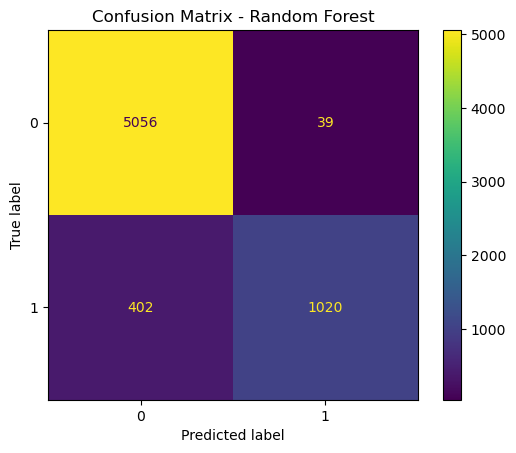

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = models["Random Forest"]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

## add classification repport 

In [ ]:
from sklearn.metrics import classification_report

best_model = models["Random Forest"]  # change based on your best result

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517



## feature importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
5,loan_percent_income,0.168063
1,person_income,0.146736
4,loan_int_rate,0.130002
3,loan_amnt,0.076720
2,person_emp_length,0.055203
17,loan_grade_D,0.053949
9,person_home_ownership_RENT,0.053517
0,person_age,0.049034
6,cb_person_cred_hist_length,0.039583
26,interest_rate_category_high,0.035869


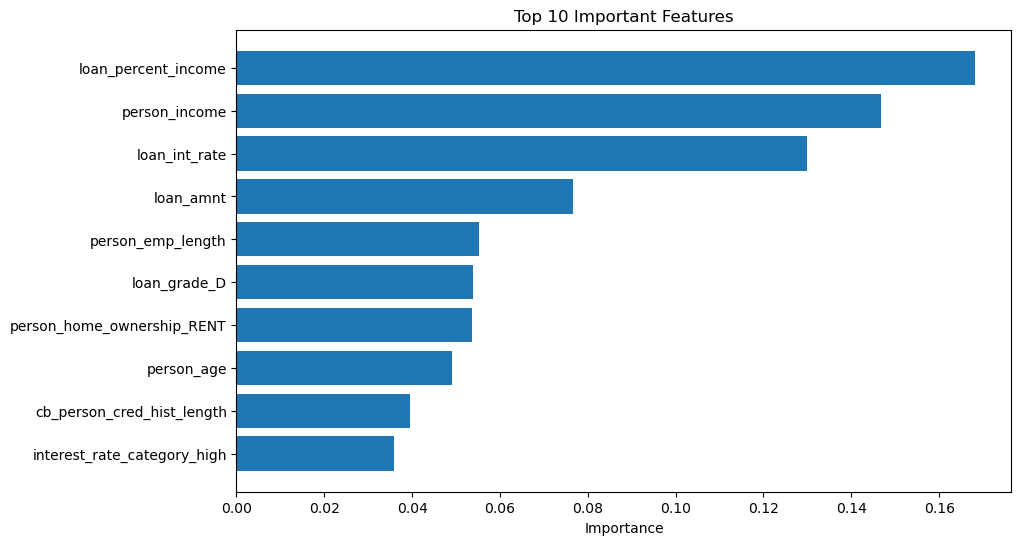

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

## tune the best model

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

NameError: name 'X_train' is not defined